In [1]:
HOME_DIR = '/Users/askhaled/Documents/MegaMouse/'
DESTINATION = 'outputs'

In [2]:
# ## Libraries

%pip install scipy==1.11.4

#libs
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn import linear_model
import pandas as pd
import numpy as np
import scikitplot as skplt
import matplotlib.pyplot as plt
from sklearn import metrics

from sklearn.pipeline import Pipeline
from sklearn import preprocessing as pp
import seaborn as sns

#import fastparquet

from sklearn.feature_selection import SelectFromModel

from joblib import dump, load

In [3]:
%matplotlib inline

In [4]:
# ## Invivo Data

# load data
mega_mouse_ML = pd.read_csv('/Users/askhaled/Documents/MegaMouse/mega_mouse_pixels2_20240701.csv')

# drop columns we cannot measure or that are redundant
cols_2_drop_mm = ['Mice','Temp', 'SatPower(uT)', 'SatTime(ms)']
mega_mouse_ML = mega_mouse_ML.drop(cols_2_drop_mm, axis = 1)

print(mega_mouse_ML.shape)

(6003, 46)


In [5]:
# Scaling CEST curves for each row
mega_mouse_ML_scaled = mega_mouse_ML

#subset = mega_mouse_ML_scaled.loc[:, '-10':'10'].copy()
#for i in range(len(mega_mouse_ML_scaled)):    
#    df1_norm = subset.iloc[i]
#    df1_norm = sklearn.preprocessing.minmax_scale(df1_norm, feature_range=(0, 1), axis=0, copy=True)
#    subset.iloc[i] = df1_norm

In [6]:
#mega_mouse_ML_scaled.loc[:, '-10':'10'] = subset;

In [7]:
#subset = mega_mouse_ML.loc[:, '-10':'10']
#plt.plot(subset.iloc[30])
#plt.show()

In [8]:

mega_mouse_ML_scaled.iloc[600];


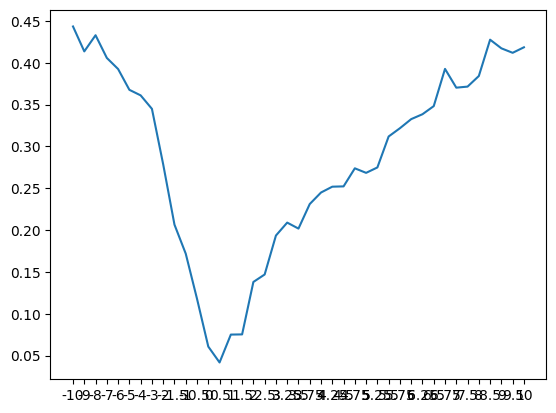

In [9]:
subset = mega_mouse_ML_scaled.loc[:, '-10':'10']
plt.plot(subset.iloc[30])
plt.show()

In [10]:
# Check if there are any NaN values in the entire DataFrame
has_nan = mega_mouse_ML_scaled.isnull().any().any()

# or equivalently
has_nan = mega_mouse_ML_scaled.isna().any().any()

print(f"DataFrame contains NaN: {has_nan}")

DataFrame contains NaN: False


In [11]:
def save_and_print(RFO, name='foo'):
    print('-----')
    for k in RFO.get_params().keys():
        print(f'{k}: {RFO.get_params()[k]}')
    
    dump(RFO, HOME_DIR + DESTINATION + f'/{name}.joblib') 



In [12]:
mega_mouse_ML_scaled_pH_threshold = mega_mouse_ML_scaled[(mega_mouse_ML_scaled['pH'] >= 6.2) & (mega_mouse_ML_scaled['pH'] <= 7.6)]

In [13]:
len(mega_mouse_ML_scaled_pH_threshold)

4129

In [14]:
mega_mouse_ML_scaled_pH_threshold.head()

,pH,ExpT1(ms),ExpT2(ms),ExpB1(percent),ExpB0(Hz),-10,-9,-8,-7,-6,...,6.25,6.5,6.75,7,7.5,8,8.5,9,9.5,10
0,7.592699,6.374522,110.291305,107.001659,255.270781,0.363055,0.347639,0.323526,0.310382,0.301379,...,0.299337,0.296639,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513
1,7.592699,1269.144062,99.848827,107.800323,254.970463,0.363055,0.347639,0.323526,0.310382,0.301379,...,0.299337,0.296639,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513
2,6.573686,2166.997710,53.693491,106.213624,289.507098,0.440031,0.413064,0.414271,0.384911,0.377109,...,0.356508,0.358590,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254
3,6.573686,2229.808614,64.256743,107.573292,300.018248,0.440031,0.413064,0.414271,0.384911,0.377109,...,0.356508,0.358590,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254
4,6.526086,2280.516739,66.785038,105.621271,263.679701,0.466261,0.455792,0.442671,0.443345,0.434089,...,0.303109,0.319266,0.335497,0.345110,0.376581,0.387007,0.385762,0.416087,0.438219,0.421897


In [15]:
Xdata_pH = mega_mouse_ML_scaled_pH_threshold.drop( ['pH'],axis=1) 
Ydata_pH = mega_mouse_ML_scaled_pH_threshold.pH

Xdata = Xdata_pH
pH_observed = Ydata_pH

------------------ Random Forest ------------------ 

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END ....max_depth=10, n_estimators=200;, score=0.447 total time=   2.4s
[CV 2/3] END ....max_depth=10, n_estimators=200;, score=0.498 total time=   2.2s
[CV 3/3] END ....max_depth=10, n_estimators=200;, score=0.442 total time=   2.8s
[CV 1/3] END ....max_depth=10, n_estimators=300;, score=0.438 total time=   3.2s
[CV 2/3] END ....max_depth=10, n_estimators=300;, score=0.500 total time=   4.0s
[CV 3/3] END ....max_depth=10, n_estimators=300;, score=0.443 total time=   3.3s
[CV 1/3] END ....max_depth=10, n_estimators=500;, score=0.442 total time=   6.2s
[CV 2/3] END ....max_depth=10, n_estimators=500;, score=0.502 total time=   5.9s
[CV 3/3] END ....max_depth=10, n_estimators=500;, score=0.443 total time=   4.3s
[CV 1/3] END ....max_depth=20, n_estimators=200;, score=0.652 total time=   3.4s
[CV 2/3] END ....max_depth=20, n_estimators=200;, score=0.676 total time=  

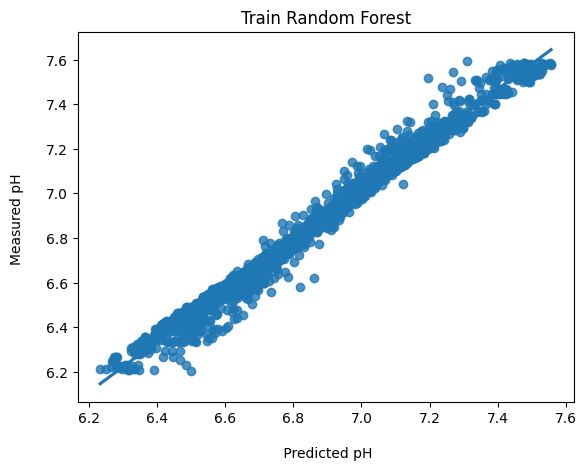

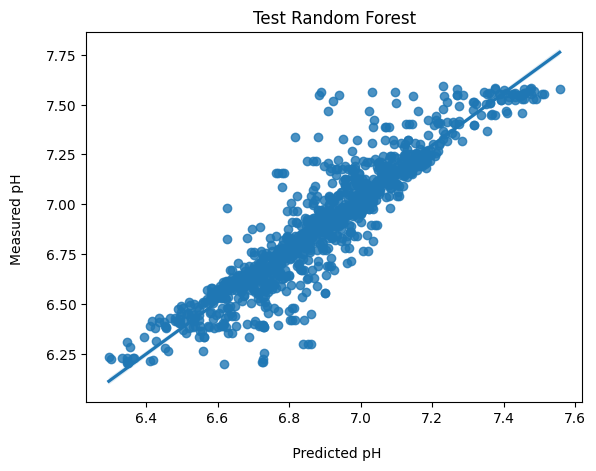

In [16]:
# ### Random Forest

# Regression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor as RFR

#def train_RFR(Xdata, pH_observed):
print('------------------ Random Forest ------------------ ')
print()
# Split data
X_train, X_test, y_train, y_test = train_test_split(Xdata, pH_observed, test_size=0.30, random_state=42)



max_f = int( 0.5 * Xdata.shape[1] )

# Regression
#param_grid = dict( n_estimators = [100,200,500], max_depth =[None], max_features=['sqrt','log2','auto',max_f], max_samples=[.10,.50], min_samples_leaf=[.01,.50] )


param_grid = dict( n_estimators = [200,300,500], max_depth =[10,20,40,None] )


# grid parameters
scorer = metrics.make_scorer( metrics.r2_score, greater_is_better = True) 

#
estimator = GridSearchCV( RFR(random_state = 42,  n_jobs = -1), param_grid, verbose = 3, cv = 3, n_jobs= 1, scoring=scorer )

# fit
estimator.fit(X_train, y_train)

score_train = np.round( 100 * metrics.mean_absolute_percentage_error(y_train , estimator.predict(X_train)), 2)
score_test  = np.round( 100 * metrics.mean_absolute_percentage_error(y_test , estimator.predict(X_test)), 2)

#score on pH units
score_pH_train = np.mean( np.abs(  y_train -  estimator.predict(X_train) ) )
score_pH_test = np.mean( np.abs(  y_test -  estimator.predict(X_test) ) )


m = f' mean absolute percentage error \n train = {score_train} % \n test  = {score_test} %'
m2 = f'\n pH units |error : \ntrain = {score_pH_train:.3f} \n test = {score_pH_test:.3f}'

#print(', '.join(Xdata.columns.to_list()))
print()
print(m,'\n',m2,'\n')
   
plt.figure()
sns.regplot(x = estimator.best_estimator_.predict(X_train), y =  y_train)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Train Random Forest')

plt.figure()
sns.regplot(x = estimator.best_estimator_.predict(X_test), y =  y_test)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Test Random Forest')

print(estimator.best_estimator_)

scores = dict()
scores['mae_train'] = score_train
scores['mae_test'] = score_test
scores['pH_train'] = score_pH_train
scores['pH_test'] = score_pH_test

test_data = dict()
test_data['X'] = X_test
test_data['Y'] = y_test

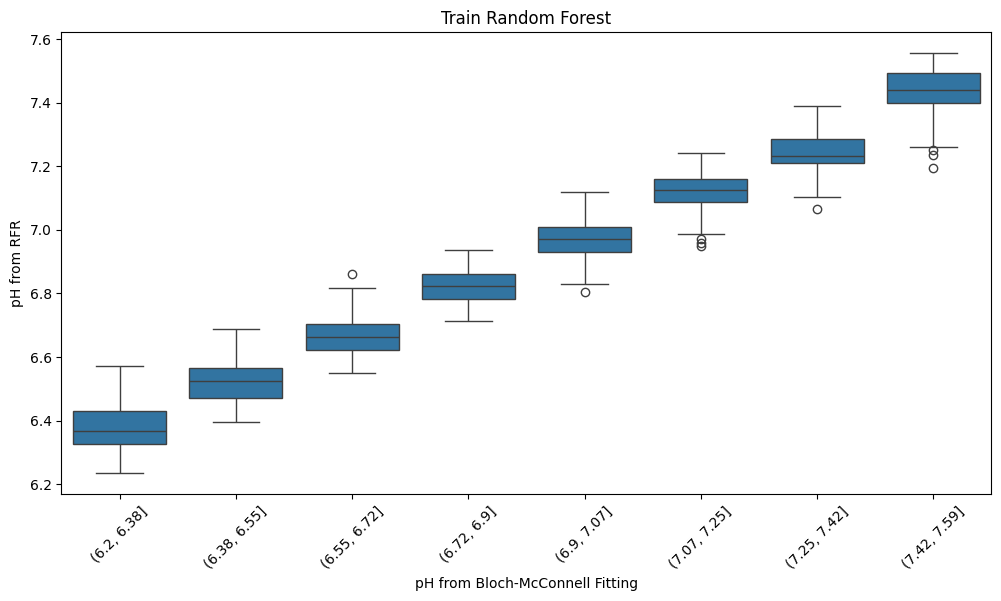

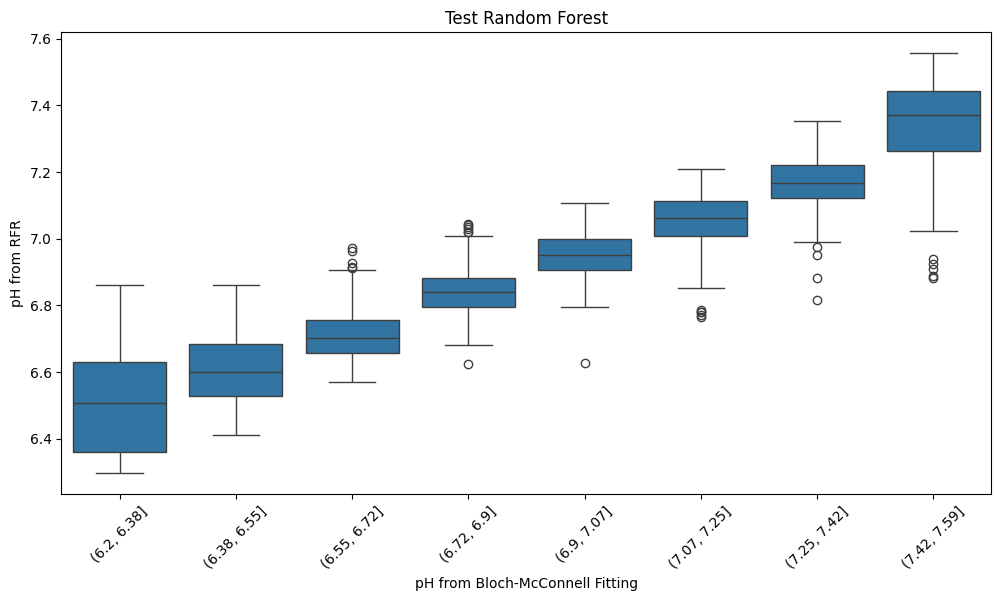

In [17]:
df = pd.DataFrame({
'value': y_train,
'prediction': estimator.best_estimator_.predict(X_train)
})

# Custom bins
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df)
plt.title('Train Random Forest')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

df = pd.DataFrame({
'value': y_test,
'prediction': estimator.best_estimator_.predict(X_test)
})

# Custom bins
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df)
plt.title('Test Random Forest')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()
    
#return estimator.best_estimator_, scores, test_data

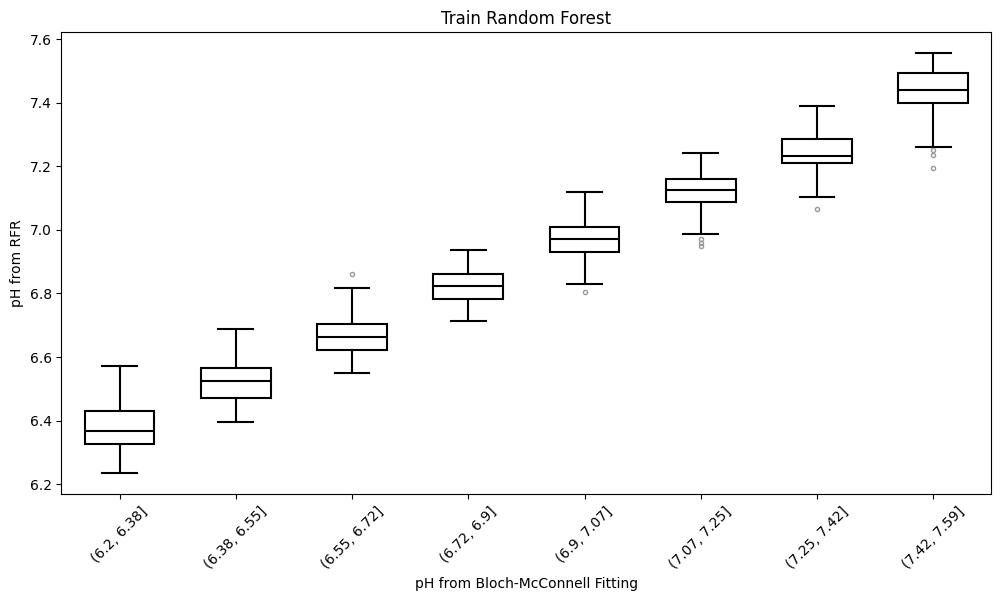

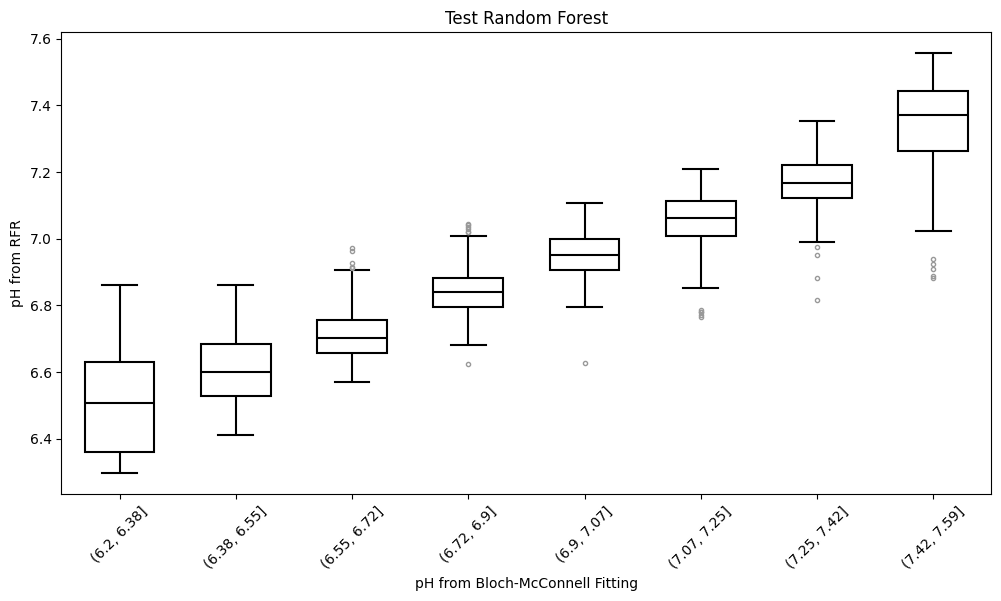

In [18]:
df = pd.DataFrame({
'value': y_train,
'prediction': estimator.best_estimator_.predict(X_train)
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df, 
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})
plt.title('Train Random Forest')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

df = pd.DataFrame({
'value': y_test,
'prediction': estimator.best_estimator_.predict(X_test)
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df, 
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})
plt.title('Test Random Forest')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()
    
#return estimator.best_estimator_, scores, test_data

In [19]:
#reg_rf_minmaxscaler_MM_pixels, _, _  = train_RFR(Xdata,Ydata)
reg_rf_minmaxscaler_MM_pixels = estimator.best_estimator_
save_and_print(reg_rf_minmaxscaler_MM_pixels, name='RF_regressor_minmaxscaler_MegaMouse_Pixels_20240905')
reg_rf_minmaxscaler_MM_pixels.save('RF_regressor_minmaxscaler_MegaMouse_Pixels_20240905.h5')

-----
bootstrap: True
ccp_alpha: 0.0
criterion: squared_error
max_depth: 40
max_features: 1.0
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 200
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


Text(0.5, 1.0, 'Random Forest Regression - Mega Mouse - minmaxscaler')

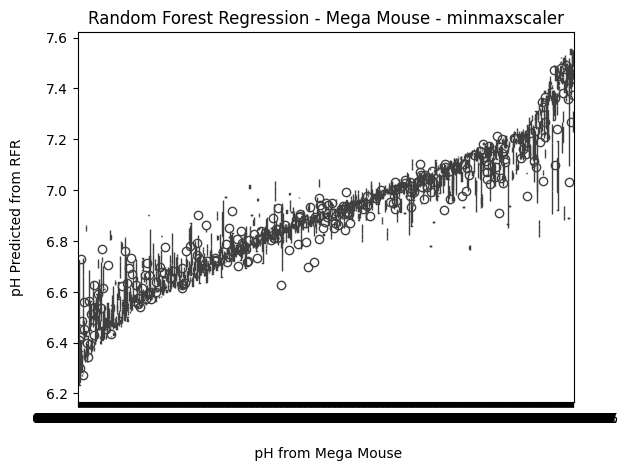

In [20]:
y_pred = reg_rf_minmaxscaler_MM_pixels.predict(Xdata)
plt.figure()
sns.boxplot(x = Ydata_pH.values, y =  y_pred)
plt.xlabel('\n pH from Mega Mouse')
plt.ylabel('pH Predicted from RFR\n')
plt.title('Random Forest Regression - Mega Mouse - minmaxscaler')

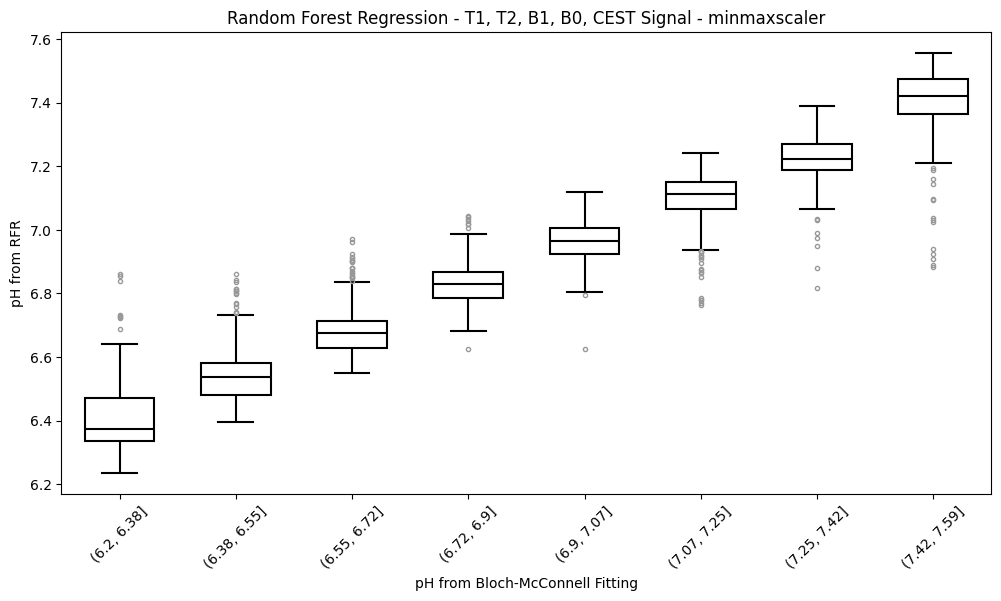

In [21]:
df = pd.DataFrame({
'value': Ydata_pH.values,
'prediction': y_pred
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df, 
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})
plt.title('Random Forest Regression - T1, T2, B1, B0, CEST Signal - minmaxscaler')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

In [22]:
mega_mouse_CEST_pH_threshold = mega_mouse_ML_scaled_pH_threshold.loc[:, '-10':'10'].copy()
mega_mouse_pH_pH_threshold = mega_mouse_ML_scaled_pH_threshold.loc[:, 'pH'].copy()

In [23]:
Xdata_CEST = mega_mouse_CEST_pH_threshold
Ydata_CEST = mega_mouse_pH_pH_threshold

Xdata = Xdata_CEST
pH_observed = Ydata_CEST

------------------ Random Forest ------------------ 

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END ....max_depth=10, n_estimators=200;, score=0.495 total time=   1.0s
[CV 2/3] END ....max_depth=10, n_estimators=200;, score=0.548 total time=   1.2s
[CV 3/3] END ....max_depth=10, n_estimators=200;, score=0.515 total time=   1.1s
[CV 1/3] END ....max_depth=10, n_estimators=300;, score=0.493 total time=   1.7s
[CV 2/3] END ....max_depth=10, n_estimators=300;, score=0.547 total time=   1.6s
[CV 3/3] END ....max_depth=10, n_estimators=300;, score=0.513 total time=   1.5s
[CV 1/3] END ....max_depth=10, n_estimators=500;, score=0.495 total time=   2.5s
[CV 2/3] END ....max_depth=10, n_estimators=500;, score=0.550 total time=   2.3s
[CV 3/3] END ....max_depth=10, n_estimators=500;, score=0.516 total time=   2.3s
[CV 1/3] END ....max_depth=20, n_estimators=200;, score=0.724 total time=   1.5s
[CV 2/3] END ....max_depth=20, n_estimators=200;, score=0.746 total time=  

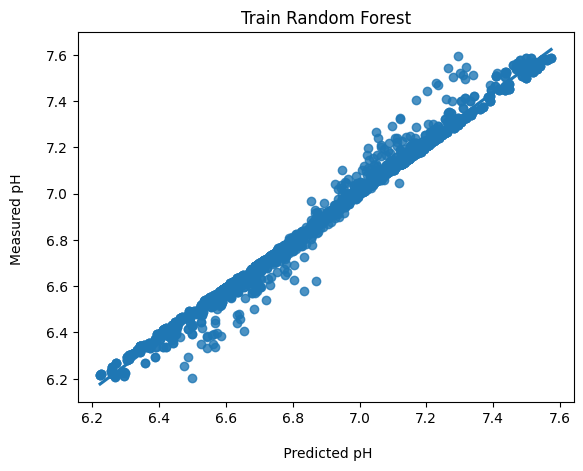

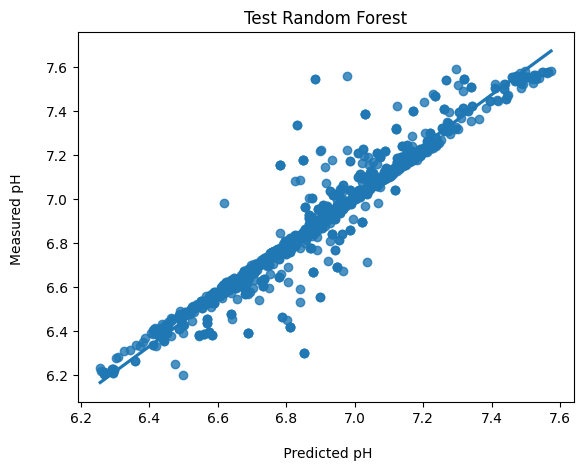

In [24]:
# ### Random Forest

# Regression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor as RFR

#def train_RFR(Xdata, pH_observed):
print('------------------ Random Forest ------------------ ')
print()
# Split data
X_train, X_test, y_train, y_test = train_test_split(Xdata, pH_observed, test_size=0.30, random_state=42)



max_f = int( 0.5 * Xdata.shape[1] )

# Regression
#param_grid = dict( n_estimators = [100,200,500], max_depth =[None], max_features=['sqrt','log2','auto',max_f], max_samples=[.10,.50], min_samples_leaf=[.01,.50] )


param_grid = dict( n_estimators = [200,300,500], max_depth =[10,20,40,None] )


# grid parameters
scorer = metrics.make_scorer( metrics.r2_score, greater_is_better = True) 

#
estimator = GridSearchCV( RFR(random_state = 42,  n_jobs = -1), param_grid, verbose = 3, cv = 3, n_jobs= 1, scoring=scorer )

# fit
estimator.fit(X_train, y_train)

score_train = np.round( 100 * metrics.mean_absolute_percentage_error(y_train , estimator.predict(X_train)), 2)
score_test  = np.round( 100 * metrics.mean_absolute_percentage_error(y_test , estimator.predict(X_test)), 2)

#score on pH units
score_pH_train = np.mean( np.abs(  y_train -  estimator.predict(X_train) ) )
score_pH_test = np.mean( np.abs(  y_test -  estimator.predict(X_test) ) )


m = f' mean absolute percentage error \n train = {score_train} % \n test  = {score_test} %'
m2 = f'\n pH units |error : \ntrain = {score_pH_train:.3f} \n test = {score_pH_test:.3f}'

#print(', '.join(Xdata.columns.to_list()))
print()
print(m,'\n',m2,'\n')
   
plt.figure()
sns.regplot(x = estimator.best_estimator_.predict(X_train), y =  y_train)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Train Random Forest')

plt.figure()
sns.regplot(x = estimator.best_estimator_.predict(X_test), y =  y_test)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Test Random Forest')

print(estimator.best_estimator_)

scores = dict()
scores['mae_train'] = score_train
scores['mae_test'] = score_test
scores['pH_train'] = score_pH_train
scores['pH_test'] = score_pH_test

test_data = dict()
test_data['X'] = X_test
test_data['Y'] = y_test

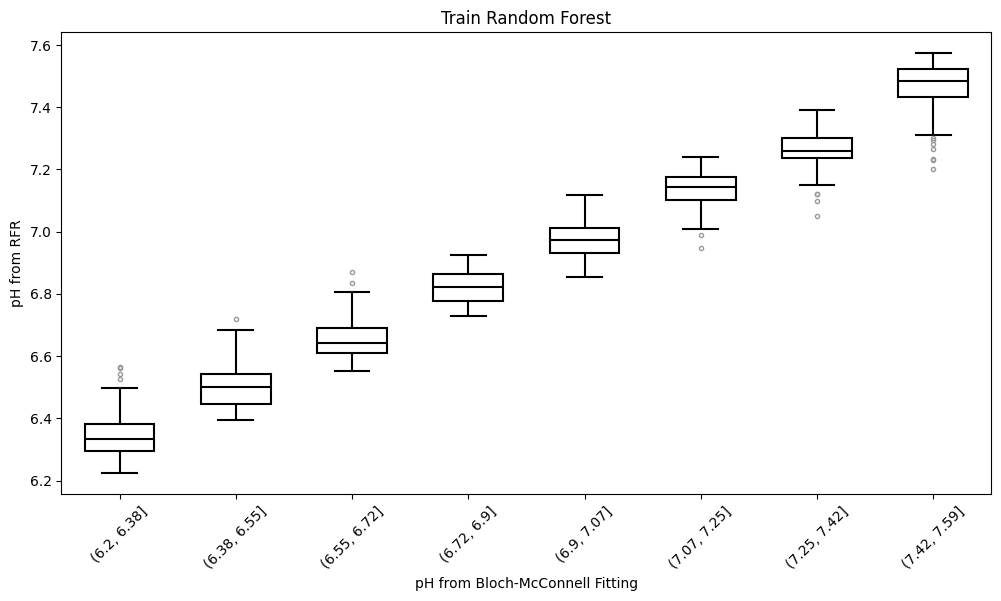

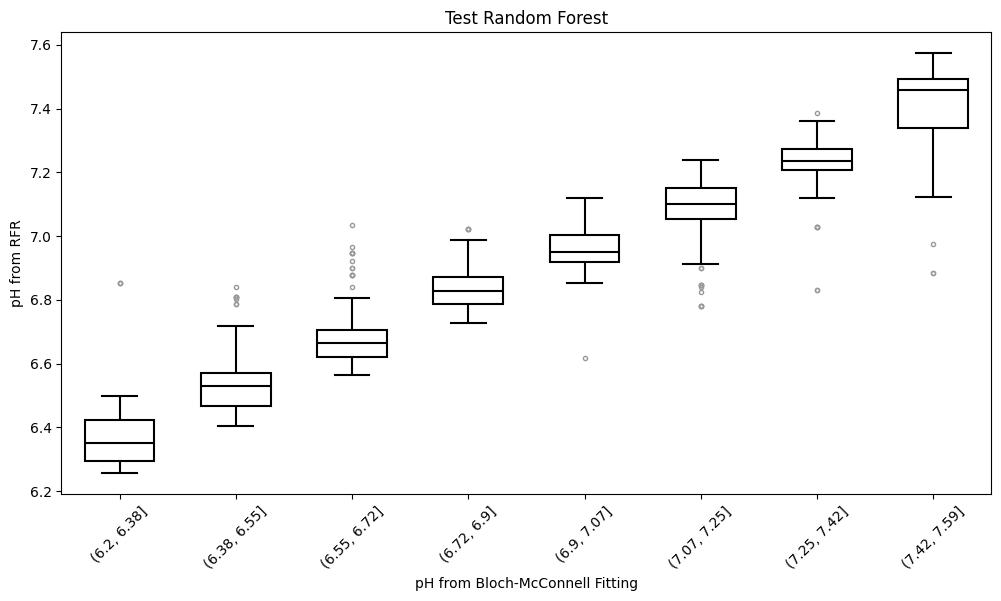

In [25]:
df = pd.DataFrame({
'value': y_train,
'prediction': estimator.best_estimator_.predict(X_train)
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df,
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})
plt.title('Train Random Forest')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

df = pd.DataFrame({
'value': y_test,
'prediction': estimator.best_estimator_.predict(X_test)
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df, 
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})

plt.title('Test Random Forest')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()
    
#return estimator.best_estimator_, scores, test_data

In [26]:
reg_rf_minmaxscaler_MM_pixels_CEST_only_pH_threshold = estimator.best_estimator_
save_and_print(reg_rf_minmaxscaler_MM_pixels_CEST_only_pH_threshold, name='RF_regressor_minmaxscaler_MegaMouse_Pixels_CEST_only_pH_threshold_20240905')
reg_rf_minmaxscaler_MM_pixels_CEST_only_pH_threshold.save('RF_regressor_minmaxscaler_MegaMouse_Pixels_CEST_only_pH_threshold_20240905.h5')

-----
bootstrap: True
ccp_alpha: 0.0
criterion: squared_error
max_depth: 40
max_features: 1.0
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 500
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


Text(0.5, 1.0, 'Random Forest Regression - Mega Mouse - minmaxscaler - CEST only')

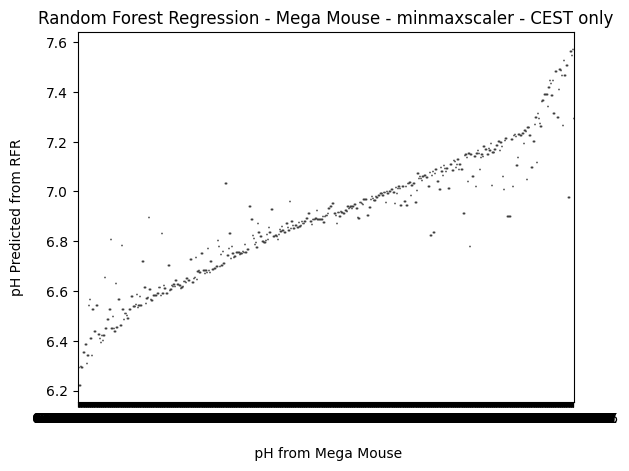

In [27]:
y_pred_CEST = reg_rf_minmaxscaler_MM_pixels_CEST_only_pH_threshold.predict(Xdata_CEST)
plt.figure()
sns.boxplot(x = Ydata_CEST.values, y =  y_pred_CEST)
plt.xlabel('\n pH from Mega Mouse')
plt.ylabel('pH Predicted from RFR\n')
plt.title('Random Forest Regression - Mega Mouse - minmaxscaler - CEST only')

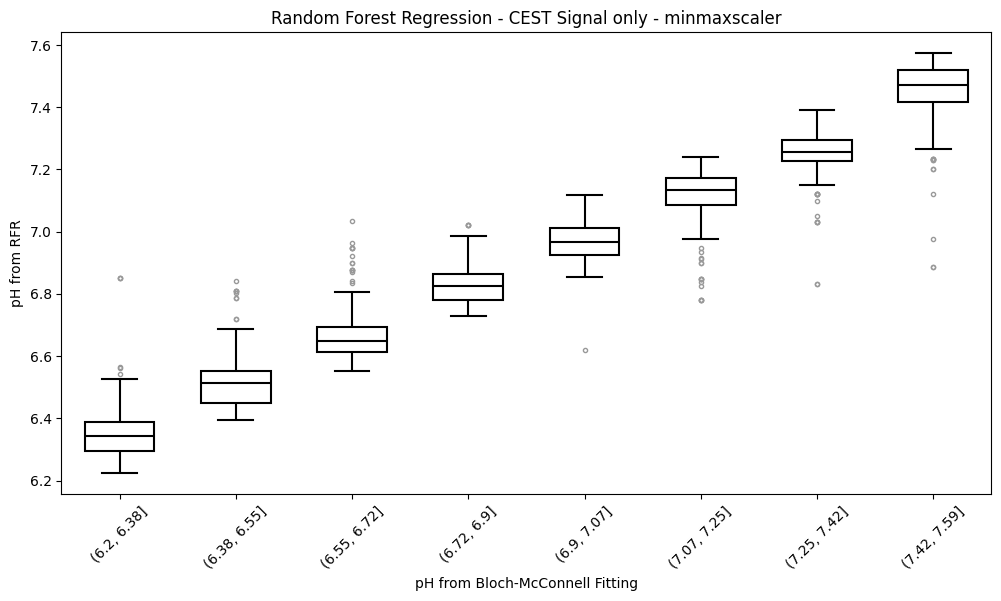

In [28]:
df = pd.DataFrame({
'value': Ydata_CEST.values,
'prediction': y_pred_CEST
})

# Custom bins
#custom_bins = pd.cut(df['value'], bins=8, precision=2)
df['value_custom_bins'] = pd.cut(df['value'], bins=8, precision=2)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='value_custom_bins', y='prediction', data=df, 
            color='white',
            linewidth=1.5,
            fliersize=3,
            width=0.6,
            medianprops={"color": "black"},
            capprops={"color": "black"},
            whiskerprops={"color": "black"},
            boxprops={"edgecolor": "black"},
            flierprops={"color": "black"})
plt.title('Random Forest Regression - CEST Signal only - minmaxscaler')
plt.xlabel('pH from Bloch-McConnell Fitting')
plt.ylabel('pH from RFR')
plt.xticks(rotation=45)
plt.show()

In [30]:
reg_rf_minmaxscaler_MM_pixels.save('RF_regressor_minmaxscaler_MegaMouse_Pixels_20240905.h5')
reg_rf_minmaxscaler_MM_pixels_CEST_only_pH_threshold.save('RF_regressor_minmaxscaler_MegaMouse_Pixels_CEST_only_pH_threshold_20240905.h5')

AttributeError: 'RandomForestRegressor' object has no attribute 'save'

In [34]:
# Predictions for the whole dataset
Xdata_pH_whole = mega_mouse_ML_scaled.drop( ['pH'],axis=1) 
y_pred_all_whole = reg_rf_minmaxscaler_MM_pixels.predict(Xdata_pH_whole)


In [37]:
Xdata_pH_CEST_whole = Xdata_pH_whole.loc[:, '-10':'10'].copy()
y_pred_CEST_whole = reg_rf_minmaxscaler_MM_pixels_CEST_only_pH_threshold.predict(Xdata_pH_CEST_whole)

In [36]:
Xdata_pH_whole.head()

,ExpT1(ms),ExpT2(ms),ExpB1(percent),ExpB0(Hz),-10,-9,-8,-7,-6,-5,...,6.25,6.5,6.75,7,7.5,8,8.5,9,9.5,10
0,6.374522,110.291305,107.001659,255.270781,0.363055,0.347639,0.323526,0.310382,0.301379,0.295964,...,0.299337,0.296639,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513
1,1269.144062,99.848827,107.800323,254.970463,0.363055,0.347639,0.323526,0.310382,0.301379,0.295964,...,0.299337,0.296639,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513
2,2166.997710,53.693491,106.213624,289.507098,0.440031,0.413064,0.414271,0.384911,0.377109,0.363356,...,0.356508,0.358590,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254
3,2229.808614,64.256743,107.573292,300.018248,0.440031,0.413064,0.414271,0.384911,0.377109,0.363356,...,0.356508,0.358590,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254
4,2280.516739,66.785038,105.621271,263.679701,0.466261,0.455792,0.442671,0.443345,0.434089,0.399077,...,0.303109,0.319266,0.335497,0.345110,0.376581,0.387007,0.385762,0.416087,0.438219,0.421897


In [39]:
mega_mouse_ML = pd.read_csv('/Users/askhaled/Documents/MegaMouse/mega_mouse_pixels2_20240701.csv')

In [40]:
mega_mouse_ML['y_pred_all_whole'] = y_pred_all_whole
mega_mouse_ML['y_pred_CEST_whole'] = y_pred_CEST_whole
mega_mouse_ML.to_csv('mega_mouse_ML_with_predictions_RF.csv', index=False)

In [41]:
mega_mouse_ML.head()

,Mice,pH,ExpT1(ms),ExpT2(ms),ExpB1(percent),ExpB0(Hz),Temp,SatPower(uT),SatTime(ms),-10,...,6.75,7,7.5,8,8.5,9,9.5,10,y_pred_all_whole,y_pred_CEST_whole
0,lucas_1_3_20230717_094926,7.592699,6.374522,110.291305,107.001659,255.270781,37,3.5,6002,0.363055,...,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513,7.229606,7.294491
1,lucas_1_3_20230717_094926,7.592699,1269.144062,99.848827,107.800323,254.970463,37,3.5,6002,0.363055,...,0.290854,0.293595,0.309636,0.325996,0.346403,0.352872,0.388528,0.448513,7.310432,7.294491
2,lucas_1_3_20230717_094926,6.573686,2166.997710,53.693491,106.213624,289.507098,37,3.5,6002,0.440031,...,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254,6.658886,6.632585
3,lucas_1_3_20230717_094926,6.573686,2229.808614,64.256743,107.573292,300.018248,37,3.5,6002,0.440031,...,0.366292,0.375612,0.409327,0.427694,0.420487,0.424310,0.433796,0.442254,6.627961,6.632585
4,lucas_1_3_20230717_094926,6.526086,2280.516739,66.785038,105.621271,263.679701,37,3.5,6002,0.466261,...,0.335497,0.345110,0.376581,0.387007,0.385762,0.416087,0.438219,0.421897,6.540039,6.547685


In [42]:
average_ph_by_mouse = mega_mouse_ML.groupby('Mice')['pH'].mean().reset_index()
print(average_ph_by_mouse.head())
average_ph_by_mouse.to_csv('average_ph_by_mouse.csv', index=False)

                       Mice        pH
0  cd_1_186_20230919_081050  7.179883
1  cd_1_187_20230919_101620  6.149249
2  cd_1_188_20230919_113227  6.121692
3  cd_1_189_20230919_125037  5.047259
4  cd_1_190_20230919_140601  7.188217


In [44]:
average_all_ph_by_mouse = mega_mouse_ML.groupby('Mice')[['pH', 'y_pred_all_whole', 'y_pred_CEST_whole']].mean().reset_index()
print(average_all_ph_by_mouse.head())
average_all_ph_by_mouse.to_csv('average_all_ph_by_mouse.csv', index=False)

                       Mice        pH  y_pred_all_whole  y_pred_CEST_whole
0  cd_1_186_20230919_081050  7.179883          7.146697           7.169635
1  cd_1_187_20230919_101620  6.149249          7.051817           7.050777
2  cd_1_188_20230919_113227  6.121692          6.628090           6.609245
3  cd_1_189_20230919_125037  5.047259          6.869782           6.856144
4  cd_1_190_20230919_140601  7.188217          7.115983           7.148334


In [45]:
std_all_ph_by_mouse = mega_mouse_ML.groupby('Mice')[['pH', 'y_pred_all_whole', 'y_pred_CEST_whole']].std().reset_index()
print(std_all_ph_by_mouse.head())
std_all_ph_by_mouse.to_csv('std_all_ph_by_mouse.csv', index=False)

                       Mice        pH  y_pred_all_whole  y_pred_CEST_whole
0  cd_1_186_20230919_081050  0.209759          0.080275           0.090024
1  cd_1_187_20230919_101620  1.132261          0.210754           0.235826
2  cd_1_188_20230919_113227  0.405546          0.164798           0.180150
3  cd_1_189_20230919_125037  0.113006          0.075660           0.081260
4  cd_1_190_20230919_140601  0.034023          0.073793           0.078430


In [29]:
import numpy as np
from scipy import stats

corr, _ = stats.pearsonr(Ydata.values, y_pred)
corr

NameError: name 'Ydata' is not defined

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(Ydata.values, y_pred)
r_value

In [ ]:
slope

In [ ]:
r_value**2

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(Ydata.values, y_pred)
mae = mean_absolute_error(Ydata.values, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(Ydata.values, y_pred)
mae = mean_absolute_error(Ydata.values, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

In [ ]:
len(y_pred)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def regression_confusion_matrix(y_true, y_pred, bins=5):
    # Determine the range of values
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    
    # Create bins
    breaks = np.linspace(min_val, max_val, bins + 1)
    
    # Assign each value to a bin
    y_true_binned = pd.cut(y_true, bins=breaks, labels=range(bins), include_lowest=True)
    y_pred_binned = pd.cut(y_pred, bins=breaks, labels=range(bins), include_lowest=True)
    
    # Create confusion matrix
    conf_matrix = pd.crosstab(y_true_binned, y_pred_binned)
    
    return conf_matrix

# Example usage
# y_true = np.random.rand(1000) * 100
# y_pred = y_true + np.random.randn(1000) * 10

# conf_matrix = regression_confusion_matrix(y_true, y_pred, bins=5)

# Visualize the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate and print MSE
mse = mean_squared_error(y_true, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

In [ ]:
regression_confusion_matrix(Ydata.values, y_pred, 10)

In [ ]:
y_pred_pH = reg_rf_minmaxscaler_MM_pixels.predict(Xdata_pH)

plt.figure()
sns.regplot(x = Ydata_pH.values, y =  y_pred_pH)
plt.xlim(6.2, 7.6)
plt.ylim(6.2, 7.6)
plt.xlabel('\n pH from Mega Mouse')
plt.ylabel('pH Predicted from RFR\n')
plt.title('Random Forest Regression - Mega Mouse - minmaxscaler')

In [ ]:
regression_confusion_matrix(Ydata_pH.values, y_pred_pH, 10)

In [ ]:
corr, _ = stats.pearsonr(Ydata_pH.values, y_pred_pH)
corr

In [ ]:
Xdata_pH = mega_mouse_ML_scaled_pH_threshold.drop( ['pH'],axis=1) 
Ydata_pH = mega_mouse_ML_scaled_pH_threshold.pH

In [ ]:
reg_rf_minmaxscaler_MM_pixels_pH_threshold2, _, _  = train_RFR(Xdata_pH,Ydata_pH)
save_and_print(reg_rf_minmaxscaler_MM_pixels_pH_threshold2, name='RF_regressor_minmaxscaler_MegaMouse_Pixels_pH_Threshold2')

In [ ]:
from joblib import load

# Load the model
reg_rf_minmaxscaler_MM_pixels_pH_threshold2 = load(HOME_DIR + DESTINATION +'/RF_regressor_minmaxscaler_MegaMouse_Pixels_pH_Threshold2.joblib')

In [ ]:
y_pred_pH = reg_rf_minmaxscaler_MM_pixels_pH_threshold2.predict(Xdata_pH)

plt.figure()
sns.regplot(x = Ydata_pH.values, y =  y_pred_pH)
plt.xlim(6.2, 7.6)
plt.ylim(6.2, 7.6)
plt.xlabel('\n pH from Mega Mouse')
plt.ylabel('pH Predicted from RFR\n')
plt.title('Random Forest Regression - Mega Mouse - minmaxscaler')

In [ ]:
data = pd.DataFrame({
    'group': Ydata_pH.values,
    'values': y_pred_pH
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='values', data=data,
            palette='Set3',  # Color palette
            width=0.6,  # Width of the boxes
            linewidth=2,  # Width of the lines
            fliersize=5,  # Size of the outlier points
            whis=1.5)  # Length of the whiskers (in terms of IQR)

plt.title('Box and Whisker Plot', fontsize=16)
plt.xlabel('Group', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.show()

In [ ]:
Ydata_pH.values


In [ ]:
y_pred_pH

In [ ]:
resulst_pH = pd.DataFrame(Ydata_pH.values, y_pred_pH)
resulst_pH

In [ ]:
corr, _ = stats.pearsonr(Ydata_pH.values, y_pred_pH)
corr

In [ ]:
print(Ydata_CEST.values)
print(y_pred_CEST)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(Ydata_CEST.values, y_pred_CEST)
mae = mean_absolute_error(Ydata_CEST.values, y_pred_CEST)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

In [ ]:
feature_names = mega_mouse_ML_scaled.drop( ['pH'],axis=1).columns 

# Get feature importances
importances = reg_rf_minmaxscaler_MM_pixels.feature_importances_
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(feature_importances['feature'], feature_importances['importance'])
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(feature_importances)

In [ ]:
mega_mouse_ML_scaled.drop( ['pH'],axis=1).columns 

In [ ]:
feature_names = mega_mouse_CEST.columns 

# Get feature importances
importances = reg_rf_minmaxscaler_MM_pixels_CEST_only.feature_importances_
feature_importances2 = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances2 = feature_importances2.sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(feature_importances2['feature'], feature_importances2['importance'])
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(feature_importances2)

6003

In [ ]:
# ### KNN

# Regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.model_selection import GridSearchCV

print('------------------ KNN ------------------ ')
print()
# Split data
X_train, X_test, y_train, y_test = train_test_split(Xdata, Ydata, test_size=0.30, random_state=42)

#Tune Parameters
parameters = {"n_neighbors": range(1, 50)}
knn_gridsearch_k = GridSearchCV(KNeighborsRegressor(), parameters)
knn_gridsearch_k.fit(X_train, y_train)

print()
print('Grid Search Best Parameters:','\n',knn_gridsearch_k.best_params_,'\n')

        
train_preds = knn_gridsearch_k.predict(X_train)
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
    
print()
print('RMSE Train:','\n',rmse,'\n')
    
test_preds = knn_gridsearch_k.predict(X_test)
mse = mean_squared_error(y_test, test_preds)
rmse = sqrt(mse)
    
print()
print('RMSE Test:','\n',rmse,'\n')

plt.figure()
sns.regplot(x = train_preds, y =  y_train)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Train KNN')
    
plt.figure()
sns.regplot(x = test_preds, y =  y_test)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Test KNN')

In [ ]:
# ### KNN

# Regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.model_selection import GridSearchCV

print('------------------ KNN ------------------ ')
print()
# Split data
X_train, X_test, y_train, y_test = train_test_split(Xdata_pH, Ydata_pH, test_size=0.30, random_state=42)

#Tune Parameters
parameters = {"n_neighbors": range(1, 50)}
knn_gridsearch_k = GridSearchCV(KNeighborsRegressor(), parameters)
knn_gridsearch_k.fit(X_train, y_train)

print()
print('Grid Search Best Parameters:','\n',knn_gridsearch_k.best_params_,'\n')

        
train_preds = knn_gridsearch_k.predict(X_train)
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
    
print()
print('RMSE Train:','\n',rmse,'\n')
    
test_preds = knn_gridsearch_k.predict(X_test)
mse = mean_squared_error(y_test, test_preds)
rmse = sqrt(mse)
    
print()
print('RMSE Test:','\n',rmse,'\n')

plt.figure()
sns.regplot(x = train_preds, y =  y_train)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Train KNN')
    
plt.figure()
sns.regplot(x = test_preds, y =  y_test)
plt.xlabel('\n Predicted pH')
plt.ylabel('Measured pH \n')
plt.title('Test KNN')